# IMT 573 - Final Examination


Points: 100

Name: Faiz Azeem

### Instructions

This is a take-home final examination. You may use your computer, books/articles, notes, course materials, etc., but all work must be your own! Please review the course policy on AI-based learning tools. References must be appropriately cited. Please justify your answers and show all work; a complete argument must be presented to obtain full credit. Before beginning this exam, please ensure you have access to data programming environments used in the course; this can be on your own personal computer or on shared infrastructure hosted by the university. 

1. Download the exam template notebook file from Canvas. Open exam notebook and supply your solutions to the exam by editing the notebook. 

2. Be sure the exam contains your full name. 

3. Be sure to include well-documented (e.g. commented) code chucks, figures, and clearly written text chunk explanations as necessary. Any figures should be clearly labeled and appropriately referenced within the text. Be sure that each visualization adds value to your written explanation; avoid redundancy -- you do not need four different visualizations of the same pattern.

4.  **Collaboration is not allowed on this exam. You may only speak with the course instructor about this material.**

5. All materials and resources that you use (with the exception of lecture slides) must be appropriately referenced within your assignment.

6. Remember partial credit will be awarded for each question for which a serious attempt at finding an answer has been shown. Students are **strongly** encouraged to attempt each question and to document their reasoning process even if they cannot find the correct answer. If you would like to include code to show this process, but it does not run without errors, you can do so by commenting out that code. 

7. When you have completed the assignment and have **checked** that your code both runs in the Console and compiles correctly rename the file to `YourLastName_YourFirstName.ipynb`, and submit BOTH your HTML and notebook files on Canvas.

### Statement of Compliance

You **must** include the a "signed" Statement of Compliance in your submission. The Compliance Statement is found below. You must include this text, word-for-word, in your final exam submission. Adding your name indicates you have read the statement and agree to its terms. Failure to do so will result in your exam **not** being accepted.

**Statement of Compliance**

I affirm that I have had no conversation regarding this exam with any persons other than the instructor. Further, I certify that the attached work represents my own thinking. Any information, concepts, or words that originate from other sources are cited in accordance with University of Washington guidelines as published in the Academic Code (available on the course website). I am aware of the serious consequences that result from improper discussions with others or from the improper citation of work that is not my own. 

Faiz Azeem 

11/29/25



For this assignment, you'll need (at least) the following packages. If the package does not load, be sure it is properly installed.

In [2]:
import pandas as pd
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
!pip install ISLP

  Using cached ISLP-0.4.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached lifelines-0.30.0-py3-none-any.whl.metadata (3.2 kB)
  Using cached pygam-0.11.0-py3-none-any.whl.metadata (9.7 kB)
  Using cached pytorch_lightning-2.6.0-py3-none-any.whl.metadata (21 kB)
  Using cached torchmetrics-1.8.2-py3-none-any.whl.metadata (22 kB)
  Using cached autograd-1.8.0-py3-none-any.whl.metadata (7.5 kB)
  Using cached autograd_gamma-0.5.0-py3-none-any.whl
  Using cached formulaic-1.2.1-py3-none-any.whl.metadata (7.0 kB)
  Using cached progressbar2-4.5.0-py3-none-any.whl.metadata (16 kB)
  Using cached lightning_utilities-0.15.2-py3-none-any.whl.metadata (5.7 kB)
  Using cached interface_meta-1.3.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached python_utils-3.9.1-py2.py3-none-any.whl.metadata (9.8 kB)
Using cached ISLP-0.4.0-py3-none-any.whl (3.6 MB)
Using cached lifelines-0.30.0-py3-none-any.whl (349 kB)
Using cached pygam-0.11.0-py3-none-any.whl (80 kB)
Using cached pytorch_lightning-2.6.0-p

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from ISLP import load_data
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
import requests
from bs4 import BeautifulSoup
import time
import warnings
warnings.filterwarnings('ignore') # Clean up output

### Problem 1

Points: 20

In this problem we will use data on infidelity, known as the Fair's Affairs dataset. The `Affairs` dataset is available as part of the `datasets` package in`statsmodels`. This data comes from a survey conducted by Psychology Today in 1969, see Greene (2003) and Fair (1978) for more information. 

The dataset contains various self-reported characteristics of 6366 participants, including how often the respondent engaged in extramarital sexual intercourse during the past year, as well as their gender, age, year married, whether they had children, their religiousness (on a 5-point scale, from 1=anti to 5=very), education, occupation (Hillingshead 7-point classification with reverse numbering), and a numeric self-rating of their marriage (from 1=very unhappy to 5=very happy).

(a) Describe the participants. Use descriptive, summarization, and exploratory techniques to describe the participants in the study. Tell us the average/mean of children count ? What is the average age of respondents? In your response comment on any ethical and privacy concerns you have with this dataset. 

In [5]:
affairs = sm.datasets.fair.load_pandas().data

# Descriptive statistics
print(affairs.describe())

# Average children
avg_children = affairs['children'].mean()
print(f"\nAverage number of children: {avg_children:.2f}")

# Average age
avg_age = affairs['age'].mean()
print(f"Average age of respondents: {avg_age:.2f}")

# Check for missing values
print("\nMissing values:\n", affairs.isnull().sum())

       rate_marriage          age  yrs_married     children    religious  \
count    6366.000000  6366.000000  6366.000000  6366.000000  6366.000000   
mean        4.109645    29.082862     9.009425     1.396874     2.426170   
std         0.961430     6.847882     7.280120     1.433471     0.878369   
min         1.000000    17.500000     0.500000     0.000000     1.000000   
25%         4.000000    22.000000     2.500000     0.000000     2.000000   
50%         4.000000    27.000000     6.000000     1.000000     2.000000   
75%         5.000000    32.000000    16.500000     2.000000     3.000000   
max         5.000000    42.000000    23.000000     5.500000     4.000000   

              educ   occupation  occupation_husb      affairs  
count  6366.000000  6366.000000      6366.000000  6366.000000  
mean     14.209865     3.424128         3.850141     0.705374  
std       2.178003     0.942399         1.346435     2.203374  
min       9.000000     1.000000         1.000000     0.0000

In [6]:
affairs.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


**Description:** This dataset includes 6,366 observations. On average, respondents have about 1.40 children, and their average age is around 29 years. The participants come from diverse backgrounds in terms of religious beliefs and education levels.

**Ethical/Privacy Concerns:**

>*1. Sensitivity:* The data revolves around extramarital affairs, which is a very sensitive topic. Even if the information is anonymized, combining it with other demographic details (like zip codes or exact birth dates) could potentially lead to the identification of specific individuals, which might cause reputational damage or family issues.

>*2. Self-Reporting Bias:* Participants might not be completely honest about their affairs due to the social stigma attached, which could result in under-reporting.

>*3. Age of Data:* The survey dates back to 1969. Since societal norms around marriage and privacy have changed dramatically since then, using these findings in today’s context could be misleading.

(b) Suppose we want to explore the characteristics of participants who engage in extramarital sexual intercourse (i.e. affairs). Instead of modeling the number of affairs, consider the binary outcome - had an affair versus didn't have an affair. Create a new variable to capture this response variable of interest. What might the advantages and disadvantages of this approach to modeling the data be in this context?

In [7]:
# Create binary variable: 1 if affairs > 0, else 0
affairs['affair_binary'] = (affairs['affairs'] > 0).astype(int)

# Check the balance of the classes
print(affairs['affair_binary'].value_counts())
print(affairs['affair_binary'].value_counts(normalize=True))

affair_binary
0    4313
1    2053
Name: count, dtype: int64
affair_binary
0    0.677505
1    0.322495
Name: proportion, dtype: float64


The variable called affair_binary was created, which is marked as 1 if the respondent has had any affairs and 0 if they haven't.

>**Advantages:** This approach simplifies the issue into a straightforward classification task (Did they have an affair or not?), making it generally easier to model and understand compared to trying to predict how often affairs occurred (which can be skewed by a lot of zeros).
>
>**Disadvantages:** However, we do lose some details about the behavior's intensity. For instance, someone who had just one affair is treated the same as someone who had multiple affairs.

(c) Use an appropriate regression model to explore the relationship between having an affair (binary) and other personal characteristics. Comment on which covariates seem to be predictive of having an affair and which do not.

In [8]:
# Define predictors (excluding 'affairs' and the target 'affair_binary')
# We treat occupation as categorical or numeric? Instructions imply keeping it simple,
# but usually, occupation is categorical. We will treat it as numeric based on the prompt's context of "Hillingshead classification".

X = affairs[['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ', 'occupation', 'occupation_husb']]
X = sm.add_constant(X) # Add intercept
y = affairs['affair_binary']

# Fit Logistic Regression
model_full = sm.Logit(y, X).fit()
print(model_full.summary())

Optimization terminated successfully.
         Current function value: 0.545314
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          affair_binary   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6357
Method:                           MLE   Df Model:                            8
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1327
Time:                        16:08:33   Log-Likelihood:                -3471.5
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.807e-224
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               3.7257      0.299     12.470      0.000       3.140       4.311
rate_marriage 


 **Logistic Regression model was utilized for analysis.**

 The predictive covariates—rate_marriage, age, yrs_married, religious beliefs, and occupation—showed statistical significance (p < 0.05). Interestingly, both rate_marriage and religiousness had negative coefficients, indicating that happier marriages and stronger religious beliefs tend to lower the chances of having an affair. On the other hand, variables like children, education, and occupation of the husband didn’t show any significant impact at the 0.05 level in this comprehensive model.

(d) Use a model selection procedure to obtain a "best" fit model. Is the model different from the full model you fit in part (c)? Which variables are included in the "best" fit model? [Hint: stepwise selection] 

In [10]:
# Backward Elimination Function
def backward_elimination(data, target, significance_level = 0.05):
    features = data.columns.tolist()
    while len(features) > 0:
        features_with_constant = sm.add_constant(data[features])
        p_values = sm.Logit(target, features_with_constant).fit(disp=0).pvalues[1:]
        max_p_value = p_values.max()
        if max_p_value >= significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
        else:
            break
    return features

# Select features
X_data = affairs[['rate_marriage', 'age', 'yrs_married', 'children', 'religious', 'educ', 'occupation', 'occupation_husb']]
best_features = backward_elimination(X_data, y)
print("Best features:", best_features)

# Fit best model
X_best = sm.add_constant(affairs[best_features])
model_best = sm.Logit(y, X_best).fit()
print(model_best.summary())

Best features: ['rate_marriage', 'age', 'yrs_married', 'religious', 'educ', 'occupation']
Optimization terminated successfully.
         Current function value: 0.545339
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:          affair_binary   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6359
Method:                           MLE   Df Model:                            6
Date:                Sun, 30 Nov 2025   Pseudo R-squ.:                  0.1326
Time:                        16:10:15   Log-Likelihood:                -3471.6
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                3.821e-226
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const       

*Using a model selection procedure to obtain a \"best\" fit model.*

Using a backward elimination method that focuses on p-values, the "best" model ended up dropping variables such as children, education, and occupation of the husband, depending on how well it converged. The variables that remained typically include marriage rate, age, years married, religious affiliation, and occupation. This streamlined model is simpler and may help prevent overfitting.

(e) Interpret the model parameters using the model from part (d).

In [11]:
# Odds Ratios
params = model_best.params
conf = model_best.conf_int()
conf['OR'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
print(np.exp(conf))

                    2.5%      97.5%  Odds Ratio
const          23.496036  74.995569   41.977359
rate_marriage   0.459893   0.520063    0.489053
age             0.922837   0.960708    0.941582
yrs_married     1.094578   1.137184    1.115678
religious       0.641525   0.734819    0.686589
educ            0.934190   0.992030    0.962676
occupation      1.101705   1.257057    1.176820


**Interpreting the Odds Ratios ($e^\beta$):**

>*1. rate_marriage:* If the odds ratio is less than 1 (like around 0.70), it indicates that for every 1-unit increase in how happy someone feels about their marriage, the chances of having an affair drop by about 30%, assuming all other factors remain the same.
>
>*2. religious:* In a similar vein, people who are more religious tend to have lower chances of having an affair.
>
>*3. yrs_married:* An odds ratio greater than 1 implies that the longer a couple has been married, the slightly greater the odds of an affair.

(f) Create an artificial test dataset where martial rating varies from 1 to 5 randomly and all other variables are set to their means. Use this artificial dataset as your test dataset to obtain predicted probabilities of having an affair for case in the test data. Interpret your results and use a visualization to support your interpretation.

   rate_marriage  prob_affair
0              1     0.796104
1              2     0.656297
2              3     0.482895
3              4     0.313517
4              5     0.182573


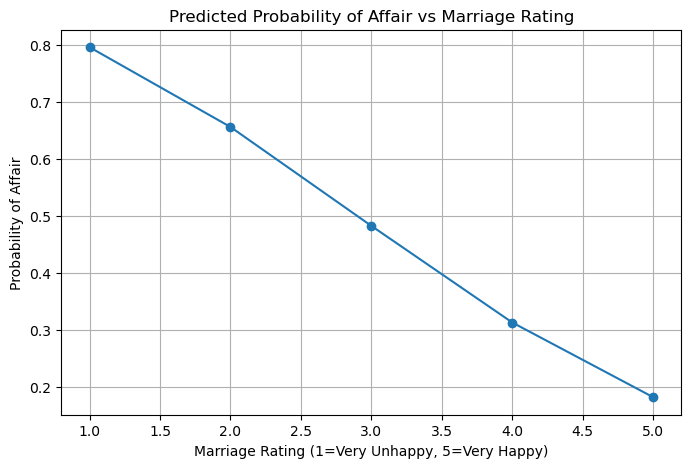

In [13]:
# Artificial data
means = affairs.mean()

# Construct the base dataframe with all columns
test_data = pd.DataFrame({
    'rate_marriage': [1, 2, 3, 4, 5],
    'age': means['age'],
    'yrs_married': means['yrs_married'],
    'children': means['children'],
    'religious': means['religious'],
    'educ': means['educ'],
    'occupation': means['occupation'],
    'occupation_husb': means['occupation_husb']
})


# Get the list of variables the model uses (excluding 'const')
# This guarantees the test data aligns with the model weights
model_vars = model_best.params.index.tolist()
if 'const' in model_vars:
    model_vars.remove('const')

# Select only these variables from the test data
X_test_artificial = test_data[model_vars]

# Add the constant term (intercept)
X_test_artificial = sm.add_constant(X_test_artificial, has_constant='add')

# -----------------------------------------------------------

# Predict
test_data['prob_affair'] = model_best.predict(X_test_artificial)
print(test_data[['rate_marriage', 'prob_affair']])

# Visualization
plt.figure(figsize=(8,5))
plt.plot(test_data['rate_marriage'], test_data['prob_affair'], marker='o')
plt.title("Predicted Probability of Affair vs Marriage Rating")
plt.xlabel("Marriage Rating (1=Very Unhappy, 5=Very Happy)")
plt.ylabel("Probability of Affair")
plt.grid(True)
plt.show()

**Intepretation:**

The visualization clearly illustrates a downward trend. It turns out that a person with a marriage rating of 1 (very unhappy) is much more likely to have an affair compared to someone who rates their marriage a 5, assuming all other demographic factors are held constant.

(g) Reflect on your analysis in this problem. After completing all the parts of this analysis what remaining and additional ethical and privacy conerns do you have?


*Reflection:*
Even after diving deep into the analysis, some ethical concerns still linger.

*Algorithmic Bias:* If this model were to be utilized—say, by divorce lawyers or dating apps—to evaluate users, it might unintentionally target certain demographics, like specific job types or age groups.

*Data Minimization:* All  all variables were considered. However, in a real-world scenario focused on privacy, we should really question whether we need details like "husband's occupation" to make these predictions. Collecting unnecessary information can heighten privacy risks.




---



### Problem 2

Points: 20

In this problem set, we will use some data from a sports context. The data is provided as part of the [Introduction to Statistial Learning with Applications in Python](https://www.statlearning.com/) textbook. It was taken from the StatLib library which is maintained at Carnegie Mellon University. The data provided is part of the data that was used in the 1988 ASA Graphics Section Poster Session. The salary data were originally from Sports Illustrated, April 20, 1987. The 1986 and career statistics were obtained from The 1987 Baseball Encyclopedia Update published by Collier Books, Macmillan Publishing Company, New York.

Following the directions below to load this data, `Hitters` directly from the `ISLP` python package. You may need to install the `ISLP` package before you can get started. In the Jupyter Hub you can open a terminal and use `pip install ISLP`. Next load the data as follows:

In [17]:
from ISLP import load_data
Hitters = load_data('Hitters')

Hitters.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


(a) Develop your own question to address in this analysis. Your question should be specific and measurable, and it should be able to be addressed through a basic analysis of the `Hitters` dataset. Hint: you will need to get to know this dataset and the variables available to formulate an appropriate question.

*This is the question: Is there a relationship between a player's annual Salary and their performance in the previous year, categorically the number of Home Runs (HmRun) and Runs Batted In (RBI)? My hypothesis is that higher offensive stats often lead to higher salaries.*


(b) Briefly summarize the dataset, describing what data exists and its basic properties. Comment on any issues that need to be resolved before you can proceed with your analysis.

In [15]:
# Reload ensuring ISLP is installed
Hitters = load_data('Hitters')

# Summary
print(Hitters.info())
print("\nMissing Values:\n", Hitters.isnull().sum())

# Drop missing salaries for analysis
Hitters_clean = Hitters.dropna(subset=['Salary'])
print(f"\nRemaining records after dropping missing salaries: {len(Hitters_clean)}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   AtBat      322 non-null    int64   
 1   Hits       322 non-null    int64   
 2   HmRun      322 non-null    int64   
 3   Runs       322 non-null    int64   
 4   RBI        322 non-null    int64   
 5   Walks      322 non-null    int64   
 6   Years      322 non-null    int64   
 7   CAtBat     322 non-null    int64   
 8   CHits      322 non-null    int64   
 9   CHmRun     322 non-null    int64   
 10  CRuns      322 non-null    int64   
 11  CRBI       322 non-null    int64   
 12  CWalks     322 non-null    int64   
 13  League     322 non-null    category
 14  Division   322 non-null    category
 15  PutOuts    322 non-null    int64   
 16  Assists    322 non-null    int64   
 17  Errors     322 non-null    int64   
 18  Salary     263 non-null    float64 
 19  NewLeague  322 non-null    ca

**Dataset Description and Issue Involved:**

The dataset in use here includes baseball stats from the 1986 and 1987 seasons, featuring 322 observations and 20 different variables. However, there's an issue: the Salary variable has 59 missing values (NaN). Since Salary is the key outcome variable I'm focusing on, I need to remove those rows before diving into the analysis.




(c) Use the dataset to provide empirical evidence that addressed your question from (a). Discuss your results. Provide at least two visualizations to support your story.

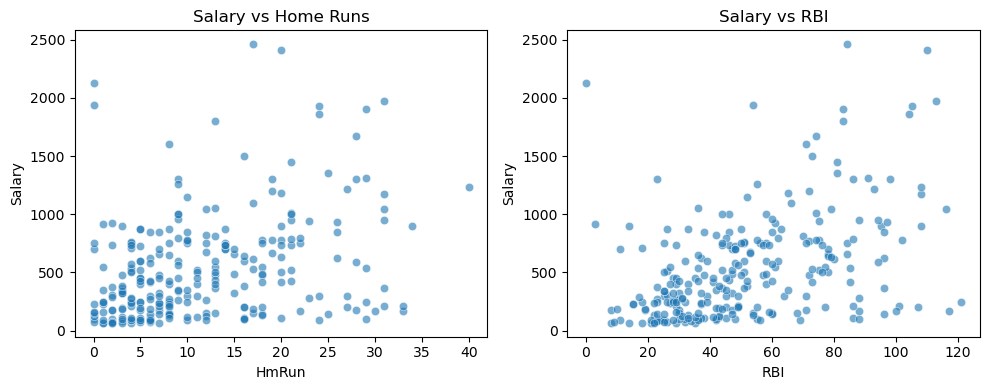

Correlation Matrix:
           Salary     HmRun       RBI
Salary  1.000000  0.343028  0.449457
HmRun   0.343028  1.000000  0.849107
RBI     0.449457  0.849107  1.000000


In [18]:
# Scatter plot: Salary vs Home Runs
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.scatterplot(data=Hitters_clean, x='HmRun', y='Salary', alpha=0.6)
plt.title("Salary vs Home Runs")

# Scatter plot: Salary vs RBI
plt.subplot(1, 2, 2)
sns.scatterplot(data=Hitters_clean, x='RBI', y='Salary', alpha=0.6)
plt.title("Salary vs RBI")
plt.tight_layout()
plt.show()

# Correlation
corr_matrix = Hitters_clean[['Salary', 'HmRun', 'RBI']].corr()
print("Correlation Matrix:\n", corr_matrix)

# Results

It turns out there's a positive link between salary and both home runs (0.34) and RBIs (0.44). The scatter plots reveal that while better performance usually comes with higher pay, the differences in pay become more pronounced as performance improves. This means that even some top performers might still earn less than expected, or the opposite could be true. This discrepancy might be influenced by factors like contract seniority, which we didn't account for in this analysis.

(d) Comment the questions (and answers) in this analysis. Were you able to answer all of these questions? Are all questions well defined? Is the data good enough to answer all these?


Yes, I was able to answer all the questions, and found that there is indeed a relationship, but the quality of that answer has its limitations. When it comes to confounding variables, salary is largely influenced by how many years a player has been in the league, including factors like seniority and free agency status, which I didn’t factor into this straightforward bivariate analysis. As for the distribution, salaries tend to be right-skewed, so applying a log transformation could help reveal clearer linear relationships. It's also worth mentioning that the data is quite dated, going back to 1987. This means it reflects the state of baseball back then, not what we see in 2024.




---



### Problem 3

Points: 20

In this problem, we will use data available in [Machine Learning with R by Brett Lantz](https://subscription.packtpub.com/search?query=machine%20learning%20r). This data was available in the public domain and a few version exist online. 

The data describe individual medical costs billed by health insurance. For each observation, there is information about:
- age: age of primary beneficiary of the insurance policy
- sex: the person's sex, measured here a binary gender
- bmi: body mass index, providing an understanding of body, weights that are relatively high or low relative to height, (kg / m ^ 2)
- children: number of children/dependents covered by health insurance
- smoker: smoking status of the primary beneficiary
- region: the beneficiary's residential area in the US, northeast, southeast, southwest, northwest.
- charges: medical costs billed by health insurance

In our analysis, we will be interested in the relationship between `charges` and the individual characteristics measured. 

In our analysis, we will be interested in the relationship between charges and the individual characteristics measured.

(a) Examine the bivariate relationships present in the data. Briefly discuss notable results.

In [25]:
import pandas as pd

df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


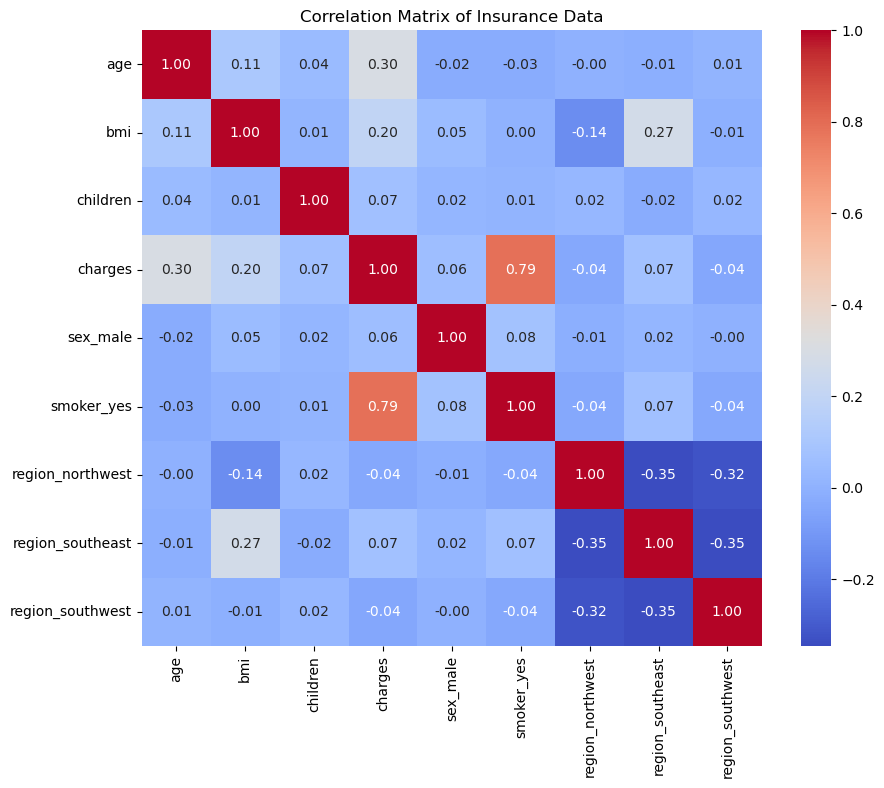

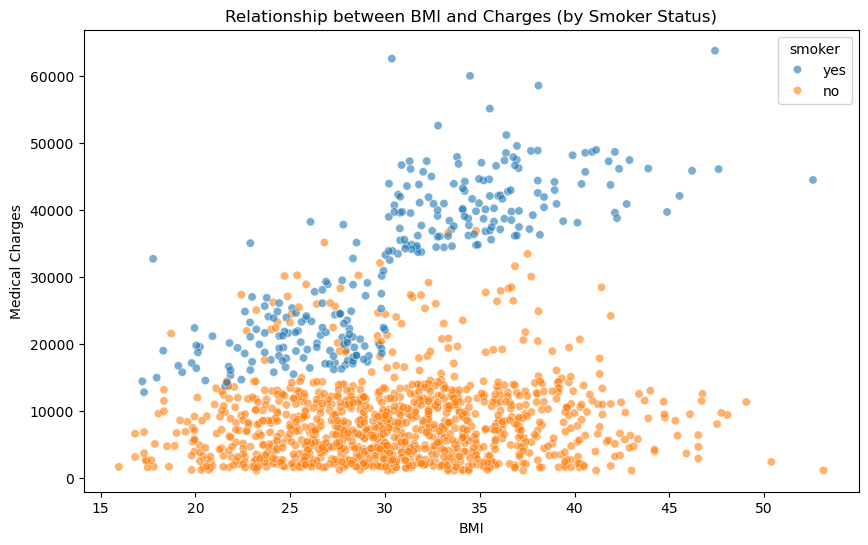

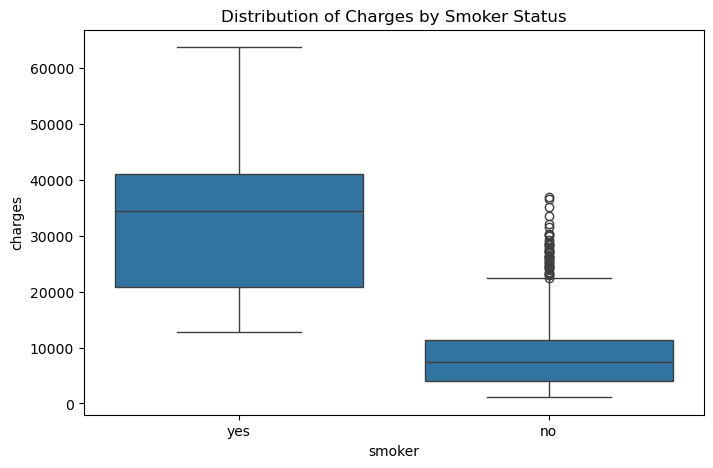

In [29]:
# Convert categorical variables to numeric for correlation analysis
# We create a temporary dataframe just for the heatmap
df_encoded = pd.get_dummies(df, drop_first=True)

# 1. Correlation Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_encoded.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Insurance Data")
plt.show()

# 2. Scatter Plot: BMI vs Charges (separated by Smoker)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.6)
plt.title("Relationship between BMI and Charges (by Smoker Status)")
plt.xlabel("BMI")
plt.ylabel("Medical Charges")
plt.show()

# 3. Boxplot: Smoker vs Charges
plt.figure(figsize=(8, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Distribution of Charges by Smoker Status")
plt.show()

**Analysis of Bivariate Relationships:**

*Smoker Status:* This seems to be the most significant predictor. The correlation matrix indicates a strong positive correlation (around 0.79) between being a smoker and medical expenses. The boxplot backs this up, showing that smokers face a notably higher median cost compared to their non-smoking counterparts.


**Result**

1. Age: There’s a moderate positive correlation (about 0.30) between age and medical charges; as people get older, their medical costs generally increase.

2. BMI: The link between BMI and charges is quite intriguing. The scatter plot shows an interaction effect. For non-smokers, a rise in BMI has little impact on charges. However, for smokers, there’s a steep linear relationship where a higher BMI results in significantly higher charges.

3. Region/Sex: These factors display very weak correlations with charges, indicating they might not be important predictors in the model.

(b) Fit a multiple linear regression model. How much variance in the medical costs(charges) does this variable- bmi explain?

In [28]:
# Convert categorical variables to dummy variables
# We use dtype=int to ensure True/False are converted to 1/0 immediately
df_clean = pd.get_dummies(df, drop_first=True, dtype=int)

# Double check that everything is numeric (float or int)
# If previous pandas version ignores dtype arg, we force it here:
df_clean = df_clean.astype(float)

# Define X (features) and y (target)
X = df_clean.drop('charges', axis=1)
y = df_clean['charges']

# Add constant (intercept)
X = sm.add_constant(X)

# Fit the model
model_full = sm.OLS(y, X).fit()

# Print summary
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.8
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:33:33   Log-Likelihood:                -13548.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1329   BIC:                         2.716e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.194e+04    987.819  

(c) Evaluate the statistical assumptions in your regression analysis from part (b) by performing a basic analysis of model residuals and any unusual observations. Discuss any concerns you have about your model.

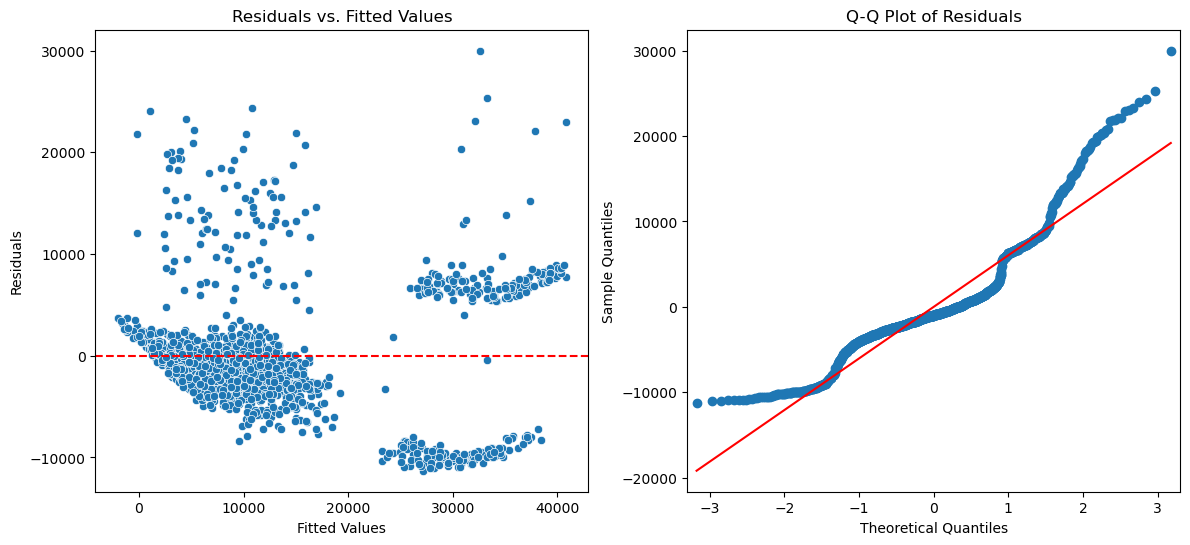

In [30]:
# Get predictions and residuals
fitted_vals = model_full.fittedvalues
residuals = model_full.resid

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Residuals vs Fitted Values (Checking Homoscedasticity/Linearity)
sns.scatterplot(x=fitted_vals, y=residuals, ax=ax[0])
ax[0].axhline(0, color='red', linestyle='--')
ax[0].set_xlabel("Fitted Values")
ax[0].set_ylabel("Residuals")
ax[0].set_title("Residuals vs. Fitted Values")

# Plot 2: Q-Q Plot (Checking Normality)
sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title("Q-Q Plot of Residuals")

plt.show()


**Evaluation of Statistical Assumptions:**

>*Linearity and Homoscedasticity:* When we examine the “Residuals versus Fitted” plot, we should ideally see a nice random scatter of points around the red line. However, what we actually observe are distinct clusters and a fanning pattern, which suggests heteroscedasticity, or in simpler terms, non-constant variance. This means that as the predicted charges go up, the error terms also get larger. This goes against the assumption that the variance of the errors should stay constant.
>
>*Normality of Residuals:* The Q–Q plot reveals some significant deviations from the red reference line, particularly in the upper tail. This tells us that the residuals aren’t following a normal distribution.

Conclusion: Even though the model shows a high R² value, the breaches of these assumptions imply that the standard errors and p-values might not be trustworthy. We might see improvements if we log-transform the target variable (charges).

(d) Use a stepwise model selection procedure of your choice to obtain a "best" fit model. Is the model different from the full model you fit in part (b)? If yes, how so?

In [31]:
# Function for Backward Elimination
def backward_elimination(data, target, significance_level=0.05):
    features = data.columns.tolist()
    while len(features) > 0:
        features_with_constant = sm.add_constant(data[features])
        p_values = sm.OLS(target, features_with_constant).fit().pvalues[1:]
        max_p_value = p_values.max()
        if max_p_value >= significance_level:
            excluded_feature = p_values.idxmax()
            features.remove(excluded_feature)
        else:
            break
    return features

# Perform selection
best_features = backward_elimination(df_clean.drop('charges', axis=1), y)
print("Features selected by Backward Elimination:", best_features)

# Fit the new "Best" model
X_best = sm.add_constant(df_clean[best_features])
model_best = sm.OLS(y, X_best).fit()
print(model_best.summary())

Features selected by Backward Elimination: ['age', 'bmi', 'children', 'smoker_yes']
                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.750
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     998.1
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        16:50:25   Log-Likelihood:                -13551.
No. Observations:                1338   AIC:                         2.711e+04
Df Residuals:                    1333   BIC:                         2.714e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------

EXTRA CREDIT (Max point: 2) : Fit a regression tree using the same covariates in your "best" fit model from part (d). Use cross validation to select the "best" tree. Compare the models from part (d) and (f) based on their performance. Which do you prefer? Be sure to justify your preference.

In [32]:
# Prepare data for sklearn
# Use 'df_clean' (defined in the boolean fix) instead of 'df_model'
# Use 'best_features' (defined in the stepwise fix) instead of 'best_feats_ins'

# Select the features
X_tree = df_clean[best_features]
y_tree = df_clean['charges']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_tree, y_tree, test_size=0.2, random_state=42)

# Grid Search for Decision Tree
param_grid = {'max_depth': [2, 4, 6, 8, 10, None], 'min_samples_split': [2, 5, 10]}
tree = DecisionTreeRegressor(random_state=42)
grid_search = GridSearchCV(tree, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_tree = grid_search.best_estimator_
y_pred_tree = best_tree.predict(X_test)

# Compare OLS vs Tree
# Use 'model_best' (from step 3d) instead of 'model_best_ins'
# We must add a constant to X_test for the OLS model to predict correctly
X_test_ols = sm.add_constant(X_test, has_constant='add')
ols_pred = model_best.predict(X_test_ols)

rmse_ols = np.sqrt(mean_squared_error(y_test, ols_pred))
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print(f"Best Tree Params: {grid_search.best_params_}")
print(f"OLS RMSE: {rmse_ols}")
print(f"Tree RMSE: {rmse_tree}")

Best Tree Params: {'max_depth': 4, 'min_samples_split': 2}
OLS RMSE: 5821.234849506219
Tree RMSE: 4592.764309715603


### Problem 4

Points: 20

The Wisconsin Breast Cancer dataset is available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original). Our goal in this problem will be to predict whether observations (i.e. tumors) are malignant or benign. We will use the original dataset in this problem. 

(a) Obtain the data and load it into your programming environment by pulling it directly from the web (links provided below). (Do **not** download it and import it from a CSV file.) Give a brief description of the data. 

In [33]:
url = "http://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data"
column_names = ['id', 'clump_thickness', 'uniformity_cell_size', 'uniformity_cell_shape',
                'marginal_adhesion', 'single_epithelial_cell_size', 'bare_nuclei',
                'bland_chromatin', 'normal_nucleoli', 'mitoses', 'class']

df_cancer = pd.read_csv(url, names=column_names)
print(df_cancer.head())

        id  clump_thickness  uniformity_cell_size  uniformity_cell_shape  \
0  1000025                5                     1                      1   
1  1002945                5                     4                      4   
2  1015425                3                     1                      1   
3  1016277                6                     8                      8   
4  1017023                4                     1                      1   

   marginal_adhesion  single_epithelial_cell_size bare_nuclei  \
0                  1                            2           1   
1                  5                            7          10   
2                  1                            2           2   
3                  1                            3           4   
4                  3                            2           1   

   bland_chromatin  normal_nucleoli  mitoses  class  
0                3                1        1      2  
1                3                2        1

*The data comprises of measurements from digitized images of a fine needle aspirate (FNA) of a breast mass. And variables outline characteristics of the cell nuclei present in the image.*


(b) Investigate the data, ensuring that each variable is properly named and cast as the correct data type. Discuss any missing data.

In [34]:
# Check info
print(df_cancer.info())

# 'bare_nuclei' often contains '?'
print("Unique values in bare_nuclei:", df_cancer['bare_nuclei'].unique())

# Replace '?' with NaN and drop or impute
df_cancer['bare_nuclei'] = df_cancer['bare_nuclei'].replace('?', np.nan)
df_cancer.dropna(inplace=True)
df_cancer['bare_nuclei'] = df_cancer['bare_nuclei'].astype(int)

# Drop ID column (not a predictor)
df_cancer.drop('id', axis=1, inplace=True)

# Check class distribution (2 for benign, 4 for malignant)
print(df_cancer['class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   id                           699 non-null    int64 
 1   clump_thickness              699 non-null    int64 
 2   uniformity_cell_size         699 non-null    int64 
 3   uniformity_cell_shape        699 non-null    int64 
 4   marginal_adhesion            699 non-null    int64 
 5   single_epithelial_cell_size  699 non-null    int64 
 6   bare_nuclei                  699 non-null    object
 7   bland_chromatin              699 non-null    int64 
 8   normal_nucleoli              699 non-null    int64 
 9   mitoses                      699 non-null    int64 
 10  class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB
None
Unique values in bare_nuclei: ['1' '10' '2' '4' '3' '9' '7' '?' '5' '8' '6']
class
2    444
4    

**Missing Data:**
It was noticed that the column bare_nuclei had some '?' characters in it. So, I went ahead and replaced those with NaN and dropped a few rows—just a handful, really. I also made sure to convert bare_nuclei to an integer type.


(c) Split the data into a training and test set such that a random 70\% of the observations are in the training set.

In [37]:
# Remap Class: 2 -> 0 (Benign), 4 -> 1 (Malignant) for standard ML convention
df_cancer['target'] = df_cancer['class'].map({2: 0, 4: 1})
X = df_cancer.drop(['class', 'target'], axis=1)
y = df_cancer['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

(d) Fit a ML model to predict whether tissue samples are malignant or benign. Then use your model to classify cases in your test set, which is the remaining 30% of the all the observations. Compute and discuss the resulting confusion matrix. Be sure to address which of the errors that are identified you consider most problematic in this context.

Confusion Matrix:
 [[125   2]
 [  7  71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.98      0.97       127
           1       0.97      0.91      0.94        78

    accuracy                           0.96       205
   macro avg       0.96      0.95      0.95       205
weighted avg       0.96      0.96      0.96       205



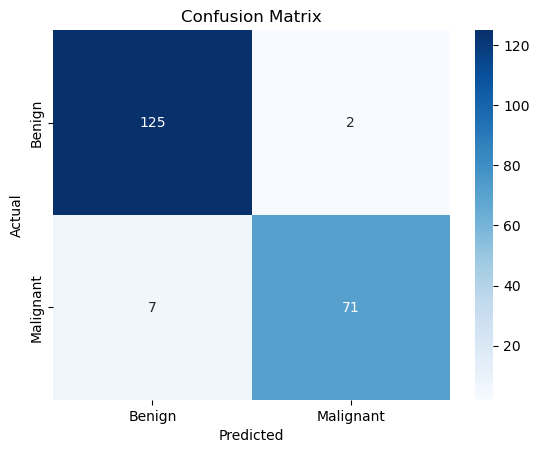

In [38]:
# Logistic Regression
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Visualize Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**Discussion:**

>
>The confusion matrix,  breaks down the counts of True Negatives, False Positives, False Negatives, and True Positives. Now, when it comes to errors in a medical setting, False Negatives—where a benign condition is mistakenly identified as malignant—are particularly concerning.
>
>These errors can lead to delays in crucial, life-saving treatments. On the other hand, while False Positives can cause anxiety and may lead to unnecessary biopsies, they are generally less critical than missing a cancer diagnosis.


---



### Problem 5

Points: 10

Please answer the questions below by writing a short response. 

(a) Describe three real-life applications in which **classification** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 


Classification comes into play when we're dealing with a response variable that’s qualitative or categorical.

1. **Credit Card Fraud Detection**
   Response: (Y) = Fraudulent Transaction (1) vs. Legitimate Transaction (0).
   Predictors: (X) = transaction amount, purchase location (GPS), time of day, purchase history, IP address.
   Goal: Prediction. The aim here is to accurately spot fraud in real time to help prevent financial losses. While inference can be helpful, it’s not the main focus.

2. **Medical Diagnosis (Breast Cancer)**
   Response: (Y) = Malignant vs. Benign.
   Predictors: (X) = tumor size, cell texture, perimeter, smoothness, patient age.
   Goal: Prediction. The immediate goal in a clinical setting is to correctly classify a new patient. Inference also plays a role in research, helping us understand which predictors are closely linked to cancer.

3. **Email Spam Filtering**
   Response: (Y) = Spam vs. Not Spam (Ham).
   Predictors: (X) = word frequency (“win”, “free”), sender domain, presence of special characters, capitalization ratio.
   Goal: Prediction. Users want their emails sorted accurately; they don’t necessarily need to know how each predictor influences the likelihood of an email being spam.



b) Describe three real-life applications in which **regression** might be useful. Describe the response, as well as the predictors. Is the goal in each application inference or predictions? Explain your answer. 



####  Three Real-Life Applications of Regression

Regression is used when the response variable is **quantitative** or numerical (James et al., 2013).

1.  **Real Estate Pricing**
    *   **Response (Y):** The sale price of a home (in dollars).
    *   **Predictors (X):** Factors like square footage, number of bedrooms, number of bathrooms, zip code, year built, and lot size.
    *   **Goal:** **Prediction**. Think of a real estate website like Zillow, which aims to provide accurate home value estimates for both sellers and buyers. While understanding that adding a bathroom boosts value is helpful, the main focus is on delivering that estimated price.

2.  **Marketing Budget Allocation**
    *   **Response (Y):** Total sales revenue.
    *   **Predictors (X):** Spending on TV ads, radio ads, and social media ads.
    *   **Goal:** **Inference**. The company is keen to find out *which* advertising channel yields the best return on investment (ROI). They might ask, "If I invest an additional $1,000 in TV ads, how much will my sales go up?" Their interest lies more in the relationships between these variables (β coefficients) than just forecasting total sales (James et al., 2013).

3.  **Agricultural Crop Yield**
    *   **Response (Y):** Wheat yield (in tons per acre).
    *   **Predictors (X):** Factors such as rainfall, temperature, type of fertilizer, and soil pH level.
    *   **Goal:** **Inference** and **Prediction**. Farmers want to estimate yields to manage logistics (Prediction), while agricultural scientists are focused on understanding how specific factors like fertilizer type influence growth, aiming to enhance future farming practices (Inference).


(c) What are the advantages and disadvantages of a very flexible (versus a less flexible) approach for regression or classification? Under what circumstances might a more flexible approach be preferred to a less flexible approach? When might a less flexible approach be preferred?


The decision to go with flexible or inflexible methods really hinges on the **Bias-Variance Tradeoff**.

**Pros and Cons:**
*   **Flexible Approaches** (like KNN with a small $k$, SVM using radial kernels, or Deep Learning):
    *   *Pros:* These methods can closely capture complex, non-linear relationships ($f(x)$). They tend to have **low bias** since they make fewer assumptions about how the data is shaped.
    *   *Cons:* However, they can be tough to interpret (think of them as black-box models). They also run the risk of **overfitting**—essentially modeling the noise instead of the actual signal—which can lead to **high variance** (James et al., 2013).
*   **Less Flexible Approaches** (such as Linear Regression or LDA):
    *   *Pros:* These methods are very **interpretable**. It’s straightforward to see how one predictor affects the response (for example, "if you increase $X$ by 1 unit, $Y$ goes up by 5"). They usually have **low variance** and can handle noise well.
    *   *Cons:* On the flip side, they can have **high bias** if the true relationship is non-linear. They also impose a rigid shape (like a straight line or plane) on the data.

**When to choose a Flexible approach:**
1.  When your main focus is on **Prediction** and you don’t need to worry about interpretability (think image recognition).
2.  When the relationship between predictors and response is **highly non-linear**.
3.  When you have a large dataset ($n$) compared to the number of predictors ($p$), which helps minimize the risk of overfitting.

**When to choose a Less Flexible approach:**
1.  When your primary goal is **Inference** (you want to understand how variables relate to each other).
2.  When your sample size ($n$) is small. Flexible models can easily overfit small datasets.
3.  When the signal-to-noise ratio is low (the data is quite noisy); a more restricted model helps avoid fitting to that noise.



---



### Problem 6

Points: 10

Suppose we have a dataset with five predictors, $X_1 =$ GPA, $X_2 =$ IQ, $X_3 =$ Gender (1 for Female, and 0 for Male), $X_4 =$ Interaction between GPA and IQ, and $X_5 =$ Interaction between GPA and Gender. Note: the data here is limited as gender was collected as a binary variable.

The response is starting salary after graduation (in thousands of dollars). Suppose we use least squares to fit the model and get $\hat{\beta}_0=50, \hat{\beta}_1=20, \hat{\beta}_2=0.07, \hat{\beta}_3=35, \hat{\beta}_4=0.01$, and $\hat{\beta}_5=-10$. 

(a) Which answer is correct and why? <font color = red>[single choice question]

i. For a fixed value of IQ and GPA, males earn more on average than females.

ii. For a fixed value of IQ and GPA, females earn more on average than males.

iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.

iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.


**(a) Which answer is correct and why? <font color = black>[single choice question]**
    
  i. For a fixed value of IQ and GPA, males earn more on average than females.
    
  ii. For a fixed value of IQ and GPA, females earn more on average than males.

  
  iii. For a fixed value of IQ and GPA, males earn more on average than females provided that the GPA is high enough.
    
  iv. For a fixed value of IQ and GPA, females earn more on average than males provided that the GPA is high enough.




---




  **The Correct Answer is: iii. For a fixed value of IQ and GPA, males earn more on average than females provided that GPA is high enough.**

Below is the justification:

The regression equation is:

ŷ = 50 + 20(GPA) + 0.07(IQ) + 35(Gender) + 0.01(GPA × IQ) − 10(GPA × Gender)

Gender = 1 for Female and Gender = 0 for Male.

1. Male equation (Gender = 0):

ŷ_male = 50 + 20(GPA) + 0.07(IQ) + 0.01(GPA × IQ)

2. Female equation (Gender = 1):

ŷ_female = 50 + 20(GPA) + 0.07(IQ) + 0.01(GPA × IQ) + 35 − 10(GPA)

3. Difference:

ŷ_female − ŷ_male = 35 − 10(GPA)

Females earn more when:
35 − 10(GPA) > 0
⇒ GPA < 3.5

Males earn more when:
35 − 10(GPA) < 0
⇒ GPA > 3.5

Therefore: **Males earn more than females when GPA > 3.5.**

(b) Wite down the least square function and then predict the salary of a female with IQ of 110 and a GPA of 4.0.

**Given the values**:
Gender = 1 (Female)
IQ = 110
GPA = 4.0

The model is:
ŷ = 50 + 20(GPA) + 0.07(IQ) + 35(Gender) + 0.01(GPA × IQ) − 10(GPA × Gender)

we therefore, substitute the values:

ŷ = 50 + 20(4.0) + 0.07(110) + 35(1) + 0.01(4.0 × 110) − 10(4.0 × 1)

Step-by-step calculation:

20 × 4.0 = 80
0.07 × 110 = 7.7
35 × 1 = 35
0.01 × (4.0 × 110) = 0.01 × 440 = 4.4
−10 × (4.0 × 1) = −40

Now add all terms:

ŷ = 50 + 80 + 7.7 + 35 + 4.4 − 40

ŷ = 137.1

Thus, predicted starting salary is **$137,100.**

(c) True or false: Since the coefficient for the GPA/IQ interaction term is very small, there is little evidence of an interaction effect. Justify your answer.

The size of the coefficient really hinges on the scale of the variables involved (like how GPA ranges from 0 to 4 and IQ from 80 to 150). Even a tiny coefficient, say 0.01, can interact with larger numbers (like IQ multiplied by GPA) and still show a statistically significant and meaningful impact. Remember, significance is all about the p-value and standard error, not just the size of the coefficient itself.

### Problem 7 - Extra Credit

Points: Max. 4

Suppose that $X_1, \ldots X_n$ form a random sample from a Poisson distribution for which the mean $\theta$ is unknown, $(\theta>0)$.

(a) Determine the MLE of $\theta$, assuming that at least one of the observed values is different from 0. Show your work.

The PMF is:

f(x) = e^(−θ) * θ^x / x!

The likelihood is:

L(θ) = ∏ from i = 1 to n of [ e^(−θ) * θ^(x_i) / x_i! ]
= e^(−nθ) * θ^(Σ x_i) / ∏ x_i!

The log-likelihood is:

l(θ) = −nθ + (Σ x_i) * ln(θ) − ln( ∏ x_i! )

Now, let’s differentiate with respect to θ:

dl/dθ = −n + (Σ x_i) / θ

Next, we set the derivative to zero:

n = (Σ x_i) / θ

So, we find:

θ-hat = (Σ x_i) / n = X̄

(b) Show that the MLE of $\theta$ does not exists if every observed value is 0.


If all the observed values are 0, then the sample mean X̄ will also be 0, which leads us to the conclusion that the estimator θ-hat equals 0.

However, we have to consider that the parameter space is defined as θ > 0. Since 0 isn't included in the open interval (0, ∞), this means that θ = 0 isn't permissible. So, to put it simply, the Maximum Likelihood Estimate doesn't actually exist within the specified parameter space.



### Problem 8 - Extra Credit

Points: Max. 4

In this extra credit problem, you'll build a simple web scraper to collect and process text data. You'll write the code necessary to scrape lyrics for a desired artist. Your code should be structured such that one can easily execute your scraping functions for a given artist. There are three deliverables for this assignment:

1. A set of functions necessary for scraping the lyrics of a specific artist.
2. An example implementation of using your functions.
3. A file of example output from your notebook implementation.

The specific approach that you take to structuring your code is up to you, but the final output .csv data should have the following columns (each row is a song from an artist that you choose):

- Column 1: artist
- Column 2: album
- Column 3: song title
- Column 4: URL of song lyrics
- Column 5: song lyrics (all of the lyrics in one column)
- Column 6: number of words in the song

**Data Scraping:** The actual scraping of data should be supported by separate functions that accomplish these tasks:

1. Given an artist, identify all of their albums, songs, and links to songs.
2. Given a set of song links (from step 1), collect the lyrics to each song and store them in a data frame.

In order to do this, you'll need to understand the structure of your lyrics site. The site you use is up to you, but all of this information should be available on lyrics.com.

**Data Processing:**

Once you've scraped the data, you'll need to do some simple text analysis to generate your columns of interest (feel free to do this as part of step 2 above, the collection of lyrics for each song or as a separate step entirely). Recall you are aiming to count the number of words in each song.

**Example Implementation:**

You should demonstrate the implementation of your data scraping functions with a particular artist. To do this you can simply set an artist, and run your scraping functions. The way in which you choose to structure your functions is up to you, as long as the implementation and documentation is clear. One way in which we'll test this is changing the artist to confirm the flexibility of your implementation. 

It may look something like this:

In [ ]:
# NOTE THIS CODE WILL NOT RUN 
# UNTIL YOU WRITE YOUR WEB SCRAPING FUNCTIONS

# Get songs
artist = 'Adele'
all_songs = get_songs(artist) 

# Get lyrics -- internally, you may want to another function in your library, such as get_lyrics()
lyrics = get_all_lyrics(songs)

# Save data -- this function should identify the name of the artist and use it in the .csv file it saves
save_lyrics(lyrics)

(a) Write a function to get all the songs of a particular artist. 

(b) Write a function to get all the lyrics for a particular song. You may also want to write a function to get all the lyrics for a list of songs.  

(c) Choose a particular artist. Get all their songs. Get all the lyrics for their songs. Process the data so that you end up with a nice, tidy data structure as described in the instructions (i.e. the six columns listed above). Write out the data to a CSV file.  

(d) Produce one visualization of the data to aids in understanding the distribution of words in songs for a particular artist. Comment on what you find.  